# Part I

## q1.1
- Answer: The number of iterations for outer loop is n^2. For the inner loop, it will be the sum of 1 to n^2, which is (n^2+1)/2
         So the total number of iterations will be [(n^2+1)*n^2]/2, which is O(n^4)


## q1.2
### This code is doing:
	• If  n=0, the function returns 1.
	• If  n=1, the function returns  x.
	• For even  n, the function makes a recursive call with n/2.
	• For odd  n, the function makes a recursive call with n/2 and multiplies the result by  x.
- The recurrence equation is T(n)=T(n/2)+O(1). And the complexity will be O(logn)

# Part II:

In [3]:
#Q2.1--insertion sort:
def insertion_sort(alist):
    for i in range(1, len(alist)):
        key = alist[i]
        j = i - 1
        while j >= 0 and key < alist[j]:
            alist[j + 1] = alist[j]
            j -= 1
        alist[j + 1] = key
# Input list
alist = [78, 21, 14, 97, 87, 62, 74, 85, 76, 45, 84, 22]
print('Input List\n', alist)
# Sort list
insertion_sort(alist)
print('Sorted List\n', alist)

Input List
 [78, 21, 14, 97, 87, 62, 74, 85, 76, 45, 84, 22]
Sorted List
 [14, 21, 22, 45, 62, 74, 76, 78, 84, 85, 87, 97]


In [2]:
#Q2.2--two-wall quick sort:
def quick_sort(alist, start, end):
    #Sorts the list from indexes start to end - 1 inclusive
    if end - start > 1:
        p = partition(alist, start, end)
        quick_sort(alist, start, p)
        quick_sort(alist, p + 1, end)
def partition(alist, start, end):
    pivot = alist[start]
    i = start + 1
    j = end - 1
    while True:
        while (i <= j and alist[i] <= pivot):
            i = i + 1
        while (i <= j and alist[j] >= pivot):
            j = j - 1
        if i <= j:
            alist[i], alist[j] = alist[j], alist[i]
        else:
            alist[start], alist[j] = alist[j], alist[start]
            return j
# Input list
alist = [78, 21, 14, 97, 87, 62, 74, 85, 76, 45, 84, 22]
print('Input List\n', alist)
# Sort list
quick_sort(alist, 0, len(alist))
print('Sorted List\n', alist)


Input List
 [78, 21, 14, 97, 87, 62, 74, 85, 76, 45, 84, 22]
Sorted List
 [14, 21, 22, 45, 62, 74, 76, 78, 84, 85, 87, 97]


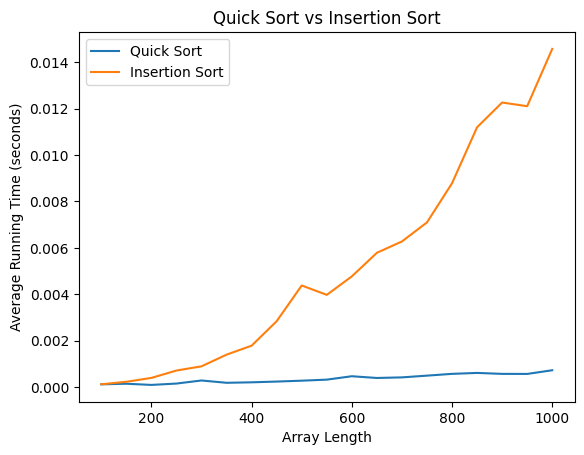

In [31]:
#q2.3:
import timeit
import matplotlib.pyplot as plt
import numpy as np

#quick sort time
def measure_running_time(algorithm, array_length):
    setup_code = f"from __main__ import {algorithm}, np; " \
                 f"array = np.random.randint(0, 1000, {array_length}).tolist()"
    stmt_code = f"{algorithm}(array,0,len(array))"
    times = timeit.repeat(stmt=stmt_code, setup=setup_code, repeat=10, number=1)
    return np.mean(times)

#insertion time
def measure_running_time_i(algorithm, array_length):
    setup_code = f"from __main__ import {algorithm}, np; " \
                 f"array = np.random.randint(0, 1000, {array_length}).tolist()"
    stmt_code = f"{algorithm}(array)"
    times = timeit.repeat(stmt=stmt_code, setup=setup_code, repeat=10, number=1)
    return np.mean(times)

array_lengths = list(range(100, 1001, 50))
quick_sort_times = [measure_running_time('quick_sort', length) for length in array_lengths]
insertion_sort_times = [measure_running_time_i('insertion_sort', length) for length in array_lengths]

plt.plot(array_lengths, quick_sort_times, label='Quick Sort')
plt.plot(array_lengths, insertion_sort_times, label='Insertion Sort')
plt.xlabel('Array Length')
plt.ylabel('Average Running Time (seconds)')
plt.legend()
plt.title('Quick Sort vs Insertion Sort')
plt.show()


In [33]:
#q3.1.1-- knapsack brute-force
def solve_knapsack(profits, weights, capacity):
    return knapsack_recursive_brute(profits, weights, capacity, 0)
def knapsack_recursive_brute(profits, weights, capacity, currentIndex):
    # base checks
    if capacity <= 0 or currentIndex >= len(profits):
        return 0
    # recursive call after choosing the element at the currentIndex
    # if the weight of the element at currentIndex exceeds the capacity, we shouldn't process this
    profit1 = 0
    if weights[currentIndex] <= capacity:
        profit1 = profits[currentIndex] + knapsack_recursive_brute(profits, weights, capacity - weights[currentIndex], currentIndex + 1)
    # recursive call after excluding the element at the currentIndex
    profit2 = knapsack_recursive_brute(profits, weights, capacity, currentIndex + 1)
    return max(profit1, profit2)
profits = [1, 6, 10, 16]
weights = [1, 2, 3, 5]
capacity = 8
print("Brute force algorithm :", solve_knapsack(profits, weights, capacity))


Brute force algorithm : 26


In [34]:
#q3.1.2--knapsack top-down
def top_down(profits, weights, capacity):
    # create a two dimensional array for Memoization, each element is initialized to '-1'
    dp = [[-1 for x in range(capacity+1)] for y in range(len(profits))]
    return topdown_recursive(dp, profits, weights, capacity, 0)
def topdown_recursive(dp, profits, weights, capacity, currentIndex):
    # base checks
    if capacity <= 0 or currentIndex >= len(profits):
        return 0
    # if we have already solved a similar problem, return the result from memory
    if dp[currentIndex][capacity] != -1:
        return dp[currentIndex][capacity]
    # recursive call after choosing the element at the currentIndex
    # if the weight of the element at currentIndex exceeds the capacity, we
    # shouldn't process this
    profit1 = 0
    if weights[currentIndex] <= capacity:
        profit1 = profits[currentIndex] + topdown_recursive(dp, profits, weights, capacity - weights[currentIndex], currentIndex + 1)
    # recursive call after excluding the element at the currentIndex
    profit2 = topdown_recursive(dp, profits, weights, capacity, currentIndex + 1)
    dp[currentIndex][capacity] = max(profit1, profit2)
    return dp[currentIndex][capacity]
profits = [1, 6, 10, 16]
weights = [1, 2, 3, 5]
capacity = 8
print("Top-down memoization :",top_down(profits, weights, capacity))


Top-down memoization : 26


In [35]:
#q3.1.3--# knapsack bottom-up
def bottom_up(profits, weights, capacity):
    # basic checks
    n = len(profits)
    if capacity <= 0 or n == 0 or len(weights) != n:
        return 0
    dp = [[0 for x in range(capacity+1)] for y in range(n)]
    # populate the capacity = 0 columns, with '0' capacity we have '0' profit
    for i in range(0, n):
        dp[i][0] = 0
    # if we have only one weight, we will take it if it is not more than the capacity
    for c in range(0, capacity+1):
        if weights[0] <= c:
            dp[0][c] = profits[0]
    # process all sub-arrays for all the capacities
    for i in range(1, n):
        for c in range(1, capacity+1):
            profit1, profit2 = 0, 0
            # include the item, if it is not more than the capacity
            if weights[i] <= c:
                profit1 = profits[i] + dp[i - 1][c - weights[i]]
            # exclude the item
            profit2 = dp[i - 1][c]
            # take maximum
            dp[i][c] = max(profit1, profit2)
    # maximum profit will be at the bottom-right corner.
    return dp[n - 1][capacity]
profits = [1, 6, 10, 16]
weights = [1, 2, 3, 5]
capacity = 8
print("Bottom-up tabulation :",bottom_up(profits, weights, capacity))


Bottom-up tabulation : 26


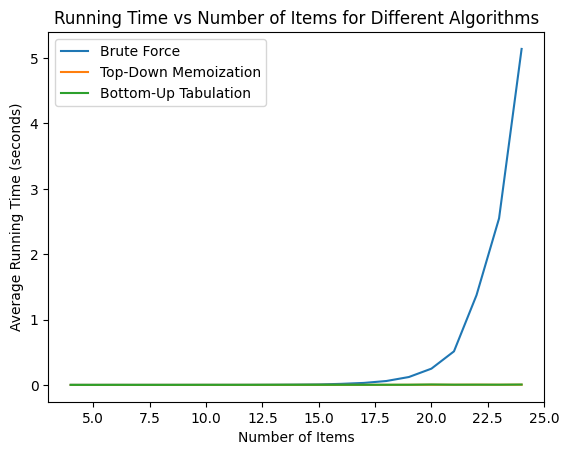

In [38]:
#q3.2 
import random
import timeit
import numpy as np
import matplotlib.pyplot as plt

# Given data
profits = [360, 83, 59, 130, 431, 67, 230, 52, 93, 125, 670, 892, 600, 38, 48, 147, 78, 256, 63, 17, 120, 164, 432,
           35, 92, 110, 22, 42, 50, 323, 514, 28, 87, 73, 78, 15, 26, 78, 210, 36, 85, 189, 274, 43, 33, 10, 19, 389,
           276, 312]
weights = [7, 0, 30, 22, 80, 94, 11, 81, 70, 64, 59, 18, 0, 36, 3, 8, 15, 42, 9, 0, 42, 47, 52, 32, 26, 48, 55, 6, 29, 84,
           2, 4, 18, 56, 7, 29, 93, 44, 71, 3, 86, 66, 31, 65, 0, 79, 20, 65, 52, 13]
capacity = 850


def measure_running_time(algorithm, profits, weights, capacity, num_items):
    selected_profits = [profits[i] for i in random.sample(range(len(profits)), num_items)]
    selected_weights = [weights[i] for i in random.sample(range(len(weights)), num_items)]
    setup_code = f"from __main__ import {algorithm}, np; " \
                 f"profits = {selected_profits}; " \
                 f"weights = {selected_weights}; " \
                 f"capacity = {capacity}"

    stmt_code = f"{algorithm}(profits, weights, capacity)"
    times = timeit.repeat(stmt=stmt_code, setup=setup_code, repeat=10, number=1)
    return np.mean(times)

# Number of items ranging from 4 to 24
num_items_range = range(4, 25)
brute_force_times = []
top_down_times = []
bottom_up_times = []

for num_items in num_items_range:
    # Measure running time for each algorithm
    brute_force_avg_time = measure_running_time('solve_knapsack', profits, weights, capacity, num_items)
    top_down_avg_time = measure_running_time('top_down', profits, weights, capacity, num_items)
    bottom_up_avg_time = measure_running_time('bottom_up', profits, weights, capacity, num_items)

    brute_force_times.append(brute_force_avg_time)
    top_down_times.append(top_down_avg_time)
    bottom_up_times.append(bottom_up_avg_time)

# Plotting
plt.plot(num_items_range, brute_force_times, label='Brute Force')
plt.plot(num_items_range, top_down_times, label='Top-Down Memoization')
plt.plot(num_items_range, bottom_up_times, label='Bottom-Up Tabulation')
plt.xlabel('Number of Items')
plt.ylabel('Average Running Time (seconds)')
plt.legend()
plt.title('Running Time vs Number of Items for Different Algorithms')
plt.show()